# Lec - 2 Randomized Experiments


## Setup Experiment Parameters and Simulate Ground truth

In [17]:
true_treatment_effect = 1
propensity_score_control = 0.3
propensity_score_treatment = 0.7
sample_size = 1000
control_effect = 10

print(f"True Treatment Effect: {true_treatment_effect}")
print(f"Propensity Score (Control): {propensity_score_control}")
print(f"Propensity Score (Treatment): {propensity_score_treatment}")
print(f"Sample Size: {sample_size}")

True Treatment Effect: 1
Propensity Score (Control): 0.3
Propensity Score (Treatment): 0.7
Sample Size: 1000


In [18]:
def simulate_ground_truth(sample_size):
  feature_p = 0.5
  feature = np.random.binomial(n=1, p=feature_p, size=sample_size)
  feature_trans= feature * 10 - 4
  potential_outcome_control = np.random.normal(loc=control_effect, scale=2, size=sample_size)
  potential_outcome_treatment = potential_outcome_control + true_treatment_effect *feature_trans

  return feature, potential_outcome_control, potential_outcome_treatment

## Experimental Designs

In [19]:

def Bernoulli_exp(propensity_score_treatment,sample_size):
  treatment_assignment = np.random.binomial(n=1, p=propensity_score_treatment, size=sample_size)
  feature, potential_outcome_control, potential_outcome_treatment = simulate_ground_truth(sample_size)
  observed_outcome = np.where(treatment_assignment == 1, potential_outcome_treatment, potential_outcome_control)
  return feature, treatment_assignment, observed_outcome
def CRE(propensity_score_treatment, sample_size):

  # For a Complete Random Experiment, a fixed number of units are assigned to treatment
  num_treated = int(propensity_score_treatment * sample_size)
  treatment_assignment = np.zeros(sample_size, dtype=int)
  treatment_assignment[:num_treated] = 1
  np.random.shuffle(treatment_assignment)

  feature, potential_outcome_control, potential_outcome_treatment = simulate_ground_truth(sample_size)
  observed_outcome = np.where(treatment_assignment == 1, potential_outcome_treatment, potential_outcome_control)
  return feature, treatment_assignment, observed_outcome

## Estimators



In [20]:
import numpy as np
def simulate_and_estimate_cre(propensity_score_treatment, sample_size):



    _,treatment_assignment, observed_outcome = CRE(propensity_score_treatment, sample_size)

    # Separate observed outcomes into treatment and control groups
    observed_outcome_treatment_group = observed_outcome[treatment_assignment == 1]
    observed_outcome_control_group = observed_outcome[treatment_assignment == 0]
    n1 = len(observed_outcome_treatment_group)
    n0 = len(observed_outcome_control_group)
    var_estimate = np.var(observed_outcome_treatment_group) / n1 + np.var(observed_outcome_control_group) / n0


    dim_estimate = np.mean(observed_outcome_treatment_group) - np.mean(observed_outcome_control_group)

    return dim_estimate, var_estimate

def simulate_and_estimate_dim(propensity_score_treatment, sample_size):



    _,treatment_assignment, observed_outcome = Bernoulli_exp(propensity_score_treatment,sample_size)

    # Separate observed outcomes into treatment and control groups
    observed_outcome_treatment_group = observed_outcome[treatment_assignment == 1]
    observed_outcome_control_group = observed_outcome[treatment_assignment == 0]
    n1 = len(observed_outcome_treatment_group)
    n0 = len(observed_outcome_control_group)
    var_estimate = np.var(observed_outcome_treatment_group) / n1 + np.var(observed_outcome_control_group) / n0


    dim_estimate = np.mean(observed_outcome_treatment_group) - np.mean(observed_outcome_control_group)


    return dim_estimate, var_estimate




In [21]:
from sklearn.linear_model import LogisticRegression
import numpy as np

def simulate_and_estimate_ipw(propensity_score_treatment, sample_size):

    _,treatment_assignment, observed_outcome = Bernoulli_exp(propensity_score_treatment,sample_size)


    # Calculate IPW weights for each individual
    # p(W=1|X) for treated, p(W=0|X) for control (simplified to constant propensity scores here)
    ipw_weights = np.where(
        treatment_assignment == 1,
        1 / propensity_score_treatment,
        1 / (1 - propensity_score_treatment)
    )

    # Calculate individual IPW estimates using the formula W*Y/p - (1-W)*Y/(1-p)
    # For treated units (W=1), the term is Y/p
    # For control units (W=0), the term is -Y/(1-p)
    individual_ipw_estimates = np.where(
        treatment_assignment == 1,
        observed_outcome * ipw_weights, # Y/p
        -observed_outcome * ipw_weights # -Y/(1-p)
    )

    # The IPW estimator is the mean of these individual estimates
    ipw_estimate = np.mean(individual_ipw_estimates)
    var_estimate = np.var(individual_ipw_estimates) / sample_size

    return ipw_estimate, var_estimate

In [22]:
def inference(estimate, var):
  return int(np.abs(estimate - true_treatment_effect) / np.sqrt(var) >= 1.96)

## Run Simulations



In [23]:
num_simulations = 1000
cre_estimates = []
cre_var_estimates = []
dim_estimates = []
dim_var_estimates = []
ipw_estimates = []
ipw_var_estimates = []
cre_err = 0
dim_err = 0
ipw_err = 0

for i in range(num_simulations):
    cre_estimate, var_est = simulate_and_estimate_cre(propensity_score_treatment, sample_size)
    cre_estimates.append(cre_estimate)
    cre_var_estimates.append(var_est)
    cre_err += inference(cre_estimate, var_est)

    # Simulate and estimate using DiM
    dim_estimate, var_est = simulate_and_estimate_dim(propensity_score_treatment, sample_size)
    dim_estimates.append(dim_estimate)
    dim_var_estimates.append(var_est)
    dim_err += inference(dim_estimate, var_est)


    # Simulate and estimate using IPW
    ipw_estimate, var_est = simulate_and_estimate_ipw(propensity_score_treatment, sample_size)
    ipw_estimates.append(ipw_estimate)
    ipw_var_estimates.append(var_est)
    ipw_err += inference(ipw_estimate, var_est)

print(f"Variance of CRE Estimate: {np.var(cre_estimates):.4f}, expectation of estimated CRE variance: {np.mean(cre_var_estimates):.4f}" )
print(f"Variance of DiM (Bernoulli) Estimate: {np.var(dim_estimates):.4f}, expectation of estimated DiM (Bernoulli) variance: {np.mean(dim_var_estimates):.4f}" )
print(f"Variance of IPW Estimate: {np.var(ipw_estimates):.4f}, expectation of estimated IPW variance: {np.mean(ipw_var_estimates):.4f}" )
print(f"CRE Error: {cre_err/num_simulations:.4f}")
print(f"DiM Error: {dim_err/num_simulations:.4f}")
print(f"IPW Error: {ipw_err/num_simulations:.4f}")

Variance of CRE Estimate: 0.0529, expectation of estimated CRE variance: 0.0546
Variance of DiM (Bernoulli) Estimate: 0.0570, expectation of estimated DiM (Bernoulli) variance: 0.0548
Variance of IPW Estimate: 0.5068, expectation of estimated IPW variance: 0.5589
CRE Error: 0.0410
DiM Error: 0.0570
IPW Error: 0.0420


## Analyze and Plot Results




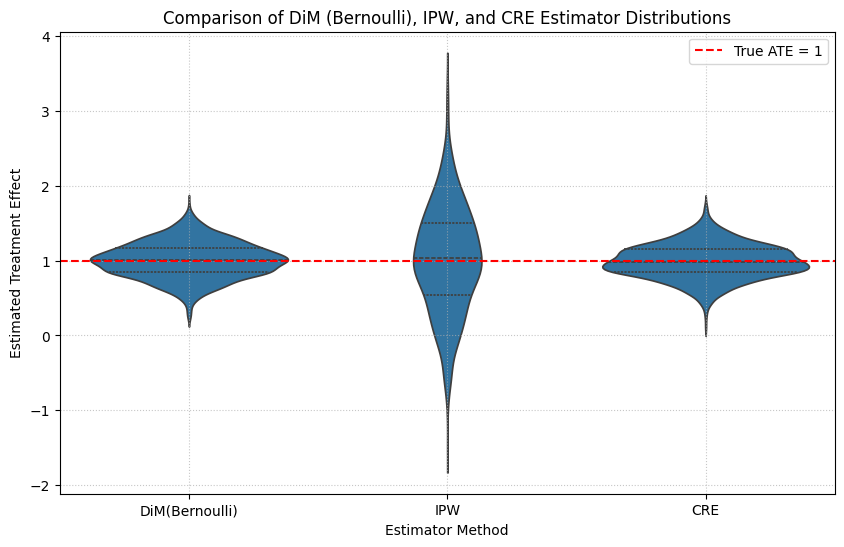

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the estimates into a DataFrame for easier plotting
data = {
    'Estimator': ['DiM(Bernoulli)'] * len(dim_estimates) + ['IPW'] * len(ipw_estimates) + ['CRE'] * len(cre_estimates),
    'Estimate': dim_estimates + ipw_estimates + cre_estimates
}
df = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_treatment_effect, color='r', linestyle='--', label=f'True ATE = {true_treatment_effect}')

# Add labels and title
plt.title('Comparison of DiM (Bernoulli), IPW, and CRE Estimator Distributions')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Stratification

### Stratified Randomized Experiments

In [31]:
def SRE(propensity_score_treatment, sample_size):

  feature_p = 0.5
  feature = np.zeros(sample_size, dtype=int)
  num_feature_one = int(feature_p * sample_size)
  feature[:num_feature_one] = 1
  np.random.shuffle(feature)

  feature_trans = feature * 10 - 4
  potential_outcome_control = np.random.normal(loc=control_effect, scale=2, size=sample_size)
  potential_outcome_treatment = potential_outcome_control + true_treatment_effect * feature_trans

  treatment_assignment = np.zeros(sample_size, dtype=int)

  # Identify indices for feature == 0 and feature == 1
  feature_0_indices = np.where(feature == 0)[0]
  feature_1_indices = np.where(feature == 1)[0]

  # Assign treatment within feature == 0 stratum (fixed number of treated units)
  num_treated_0 = int(propensity_score_treatment * len(feature_0_indices))
  temp_assignment_0 = np.zeros(len(feature_0_indices), dtype=int)
  temp_assignment_0[:num_treated_0] = 1
  np.random.shuffle(temp_assignment_0)
  treatment_assignment[feature_0_indices] = temp_assignment_0

  # Assign treatment within feature == 1 stratum (fixed number of treated units)
  num_treated_1 = int(propensity_score_treatment * len(feature_1_indices))
  temp_assignment_1 = np.zeros(len(feature_1_indices), dtype=int)
  temp_assignment_1[:num_treated_1] = 1
  np.random.shuffle(temp_assignment_1)
  treatment_assignment[feature_1_indices] = temp_assignment_1

  # Calculate observed outcome
  observed_outcome = np.where(treatment_assignment == 1, potential_outcome_treatment, potential_outcome_control)

  return feature, treatment_assignment, observed_outcome



#### Estimator in SRE


In [28]:
def simulate_and_estimate_stra(propensity_score_treatment, sample_size):

    feature, treatment_assignment, observed_outcome = SRE(propensity_score_treatment, sample_size)

    # Filter data for feature == 0
    feature_0_indices = (feature == 0)
    ta_feature_0 = treatment_assignment[feature_0_indices]
    oo_feature_0 = observed_outcome[feature_0_indices]

    # Calculate DiM for feature == 0
    oo_feature_0_treatment = oo_feature_0[ta_feature_0 == 1]
    oo_feature_0_control = oo_feature_0[ta_feature_0 == 0]

    dim_feature_0 = np.mean(oo_feature_0_treatment) - np.mean(oo_feature_0_control)
    var_estimate_0 = np.var(oo_feature_0_treatment)/len(oo_feature_0_treatment) + np.var(oo_feature_0_control)/len(oo_feature_0_control)

    # Filter data for feature == 1
    feature_1_indices = (feature == 1)
    ta_feature_1 = treatment_assignment[feature_1_indices]
    oo_feature_1 = observed_outcome[feature_1_indices]

    # Calculate DiM for feature == 1
    oo_feature_1_treatment = oo_feature_1[ta_feature_1 == 1]
    oo_feature_1_control = oo_feature_1[ta_feature_1 == 0]

    dim_feature_1 = np.mean(oo_feature_1_treatment) - np.mean(oo_feature_1_control)
    var_estimate_1= np.var(oo_feature_1_treatment)/len(oo_feature_1_treatment) + np.var(oo_feature_1_control)/len(oo_feature_1_control)


    return (dim_feature_0 + dim_feature_1)/2, 1/4 * (var_estimate_0 + var_estimate_1)

### Post-Stratification Estimator

In [29]:
def simulate_and_estimate_post_strata(propensity_score_treatment, sample_size):

    feature, treatment_assignment, observed_outcome = Bernoulli_exp(propensity_score_treatment, sample_size)

    # Filter data for feature == 0
    feature_0_indices = (feature == 0)
    ta_feature_0 = treatment_assignment[feature_0_indices]
    oo_feature_0 = observed_outcome[feature_0_indices]

    # Calculate DiM for feature == 0
    oo_feature_0_treatment = oo_feature_0[ta_feature_0 == 1]
    oo_feature_0_control = oo_feature_0[ta_feature_0 == 0]

    dim_feature_0 = np.mean(oo_feature_0_treatment) - np.mean(oo_feature_0_control)
    var_estimate_0 = np.var(oo_feature_0_treatment)/len(oo_feature_0_treatment) + np.var(oo_feature_0_control)/len(oo_feature_0_control)

    # Filter data for feature == 1
    feature_1_indices = (feature == 1)
    ta_feature_1 = treatment_assignment[feature_1_indices]
    oo_feature_1 = observed_outcome[feature_1_indices]

    # Calculate DiM for feature == 1
    oo_feature_1_treatment = oo_feature_1[ta_feature_1 == 1]
    oo_feature_1_control = oo_feature_1[ta_feature_1 == 0]

    dim_feature_1 = np.mean(oo_feature_1_treatment) - np.mean(oo_feature_1_control)
    var_estimate_1= np.var(oo_feature_1_treatment)/len(oo_feature_1_treatment) + np.var(oo_feature_1_control)/len(oo_feature_1_control)

    return (dim_feature_0 + dim_feature_1)/2, 1/4 * (var_estimate_0 + var_estimate_1)


## Run Simulations with Stratified DiM




In [32]:
# Initialize new lists for stratified DiM estimates
post_stratified_estimates = []
post_stratified_var_estimates =[]
stra_estimates = []
stra_var_estimates = []
post_err = 0
strat_err = 0

for i in range(num_simulations):
    stra_est, var_est = simulate_and_estimate_stra(propensity_score_treatment, sample_size)
    stra_estimates.append(stra_est)
    stra_var_estimates.append(var_est)
    strat_err += inference(stra_est, var_est)

    post_strata_est, var_est = simulate_and_estimate_post_strata(propensity_score_treatment, sample_size)
    post_stratified_estimates.append(post_strata_est)
    post_stratified_var_estimates.append(var_est)
    post_err += inference(stra_est, var_est)
print(f"Variance of SRE Estimate: {np.var(stra_estimates):.4f}, expectation of estimated SRE variance: {np.mean(stra_var_estimates):.4f}" )
print(f"Variance of Post-Stratification Estimate: {np.var(post_stratified_estimates):.4f}, expectation of Post-Stratification variance: {np.mean(post_stratified_var_estimates):.4f}" )

print(f"SRE Error: {strat_err/num_simulations:.4f}")
print(f"Post-Stratification Error: {post_err /num_simulations:.4f}")

Variance of SRE Estimate: 0.0190, expectation of estimated SRE variance: 0.0190
Variance of Post-Stratification Estimate: 0.0196, expectation of Post-Stratification variance: 0.0190
SRE Error: 0.0530
Post-Stratification Error: 0.0590


In [ ]:
print(f"Variance of CRE Estimate: {np.var(cre_estimates):.4f}, expectation of estimated CRE variance: {np.mean(cre_var_estimates):.4f}" )
print(f"Variance of DiM (Bernoulli) Estimate: {np.var(dim_estimates):.4f}, expectation of estimated DiM (Bernoulli) variance: {np.mean(dim_var_estimates):.4f}" )
print(f"Variance of IPW Estimate: {np.var(ipw_estimates):.4f}, expectation of estimated IPW variance: {np.mean(ipw_var_estimates):.4f}" )

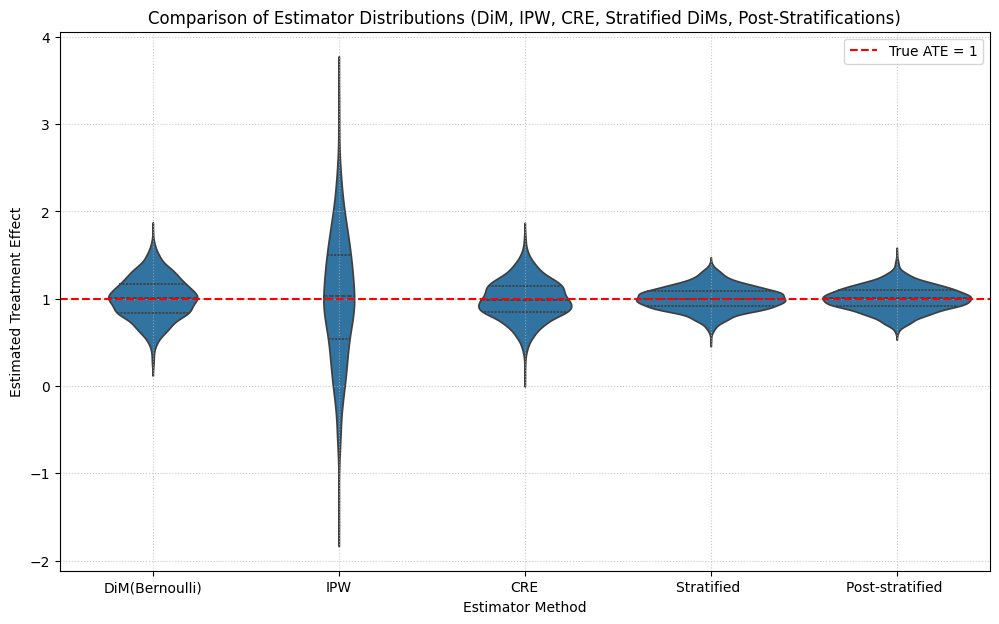

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine all estimates into a DataFrame for easier plotting
data = {
    'Estimator': ['DiM(Bernoulli)'] * len(dim_estimates) +
                 ['IPW'] * len(ipw_estimates) +
                 ['CRE'] * len(cre_estimates) +
                 ['Stratified '] * len(stra_estimates) +
                 ['Post-stratified '] * len(post_stratified_estimates) ,

    'Estimate': dim_estimates +
                ipw_estimates +
                cre_estimates +
                stra_estimates +
                post_stratified_estimates

}
df = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(12, 7))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_treatment_effect, color='r', linestyle='--', label=f'True ATE = {true_treatment_effect}')

# Add labels and title
plt.title('Comparison of Estimator Distributions (DiM, IPW, CRE, Stratified DiMs, Post-Stratifications)')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [34]:
import numpy as np

# Calculate MSE for DiM (Bernoulli)
mse_dim = np.mean((np.array(dim_estimates) - true_treatment_effect)**2)

# Calculate MSE for IPW
mse_ipw = np.mean((np.array(ipw_estimates) - true_treatment_effect)**2)

# Calculate MSE for CRE
mse_cre = np.mean((np.array(cre_estimates) - true_treatment_effect)**2)

# Calculate MSE for Post-stratified DiM
mse_post_stratified = np.mean((np.array(post_stratified_estimates) - true_treatment_effect)**2)

# Calculate MSE for Stratified DiM (SRE Data)
mse_stra = np.mean((np.array(stra_estimates) - true_treatment_effect)**2)

print(f"MSE for CRE: {mse_cre:.4f}")
print(f"MSE for DiM (Bernoulli): {mse_dim:.4f}")
print(f"MSE for IPW: {mse_ipw:.4f}")
print(f"MSE for Stratified DiM (SRE Data): {mse_stra:.4f}")
print(f"MSE for Post-stratified DiM: {mse_post_stratified:.4f}")

print("")

print(f"Variance of CRE Estimate: {np.var(cre_estimates):.4f}, expectation of estimated CRE variance: {np.mean(cre_var_estimates):.4f}" )
print(f"Variance of DiM (Bernoulli) Estimate: {np.var(dim_estimates):.4f}, expectation of estimated DiM (Bernoulli) variance: {np.mean(dim_var_estimates):.4f}" )
print(f"Variance of IPW Estimate: {np.var(ipw_estimates):.4f}, expectation of estimated IPW variance: {np.mean(ipw_var_estimates):.4f}" )
print(f"Variance of SRE Estimate: {np.var(stra_estimates):.4f}, expectation of estimated SRE variance: {np.mean(stra_var_estimates):.4f}" )
print(f"Variance of Post-Stratification Estimate: {np.var(post_stratified_estimates):.4f}, expectation of Post-Stratification variance: {np.mean(post_stratified_var_estimates):.4f}" )

MSE for CRE: 0.0530
MSE for DiM (Bernoulli): 0.0571
MSE for IPW: 0.5070
MSE for Stratified DiM (SRE Data): 0.0190
MSE for Post-stratified DiM: 0.0196

Variance of CRE Estimate: 0.0529, expectation of estimated CRE variance: 0.0546
Variance of DiM (Bernoulli) Estimate: 0.0570, expectation of estimated DiM (Bernoulli) variance: 0.0548
Variance of IPW Estimate: 0.5068, expectation of estimated IPW variance: 0.5589
Variance of SRE Estimate: 0.0190, expectation of estimated SRE variance: 0.0190
Variance of Post-Stratification Estimate: 0.0196, expectation of Post-Stratification variance: 0.0190


## Regression Adjustment

In [ ]:
import statsmodels.formula.api as smf

def simulate_and_estimate_regression_adjustment(propensity_score_treatment, sample_size):
    feature, treatment_assignment, observed_outcome = Bernoulli_exp(propensity_score_treatment, sample_size)

    # Create a DataFrame for regression
    data = pd.DataFrame({
        'observed_outcome': observed_outcome,
        'treatment_assignment': treatment_assignment,
        'feature': feature
    })

    # Fit a linear regression model: Y ~ W + X + W*X
    model = smf.ols('observed_outcome ~ treatment_assignment*feature', data=data).fit()

    # The ATE estimate is the coefficient of treatment_assignment plus the interaction term's coefficient multiplied by the mean of feature
    ra_estimate = model.params['treatment_assignment'] + model.params['treatment_assignment:feature'] * np.mean(feature)

    residuals = model.resid
    var_est = np.var(residuals[treatment_assignment == 1])/np.sum(treatment_assignment) + np.var(residuals[treatment_assignment == 0])/np.sum(1-treatment_assignment)
    var_est = var_est +  np.var(feature) * model.params['treatment_assignment:feature']**2 / sample_size


    return ra_estimate, var_est

In [ ]:
reg_estimates = []
reg_var_estimates =[]
reg_err = 0


for i in range(num_simulations):
    reg_est, var_est = simulate_and_estimate_regression_adjustment(propensity_score_treatment, sample_size)
    reg_estimates.append(reg_est)
    reg_var_estimates.append(var_est)
    reg_err += inference(reg_est, var_est)

print(f"Variance of Reg Estimate: {np.var(reg_estimates):.4f}, expectation of estimated Rerg variance: {np.mean(reg_var_estimates):.4f}" )
print("Regression Adjustment error", reg_err / num_simulations)

In [ ]:
import statsmodels.formula.api as smf


feature, treatment_assignment, observed_outcome = Bernoulli_exp(propensity_score_treatment, sample_size)
data = pd.DataFrame({
  'observed_outcome': observed_outcome,
  'treatment_assignment': treatment_assignment,
  'feature': feature
})

# Fit a linear regression model: Y ~ W + X + W*X
model = smf.ols('observed_outcome ~ treatment_assignment*feature', data=data).fit()

# The ATE estimate is the coefficient of treatment_assignment plus the interaction term's coefficient multiplied by the mean of feature
ra_estimate = model.params['treatment_assignment'] + model.params['treatment_assignment:feature'] * np.mean(feature)

residuals = model.resid
var_est = np.var(residuals[treatment_assignment == 1])/np.sum(treatment_assignment) + np.var(residuals[treatment_assignment == 0])/np.sum(1-treatment_assignment)
var_est = var_est +  np.var(feature) * model.params['treatment_assignment:feature']**2 / sample_size
print(f"Directly regress with interaction: {ra_estimate:.4f} {var_est:.4f}")

# Create a DataFrame for regression
dataT = pd.DataFrame({
  'observed_outcome': observed_outcome[treatment_assignment == 1],
  'feature': feature [treatment_assignment == 1]
})
dataC = pd.DataFrame({
  'observed_outcome': observed_outcome[treatment_assignment == 0],
  'feature': feature [treatment_assignment == 0]
})

# Fit a linear regression model: Y ~ W + X
modelT= smf.ols('observed_outcome ~ feature', data=dataT).fit()
modelC= smf.ols('observed_outcome ~ feature', data=dataC).fit()
#print(modelT.params['Intercept'], modelC.params['Intercept'], modelT.params['feature'], modelC.params['feature'], np.mean(feature))

# The ATE estimate is the coefficient of treatment_assignment
ra_estimate =  modelT.params['Intercept']  - modelC.params['Intercept'] + (modelT.params['feature'] - modelC.params['feature']) * np.mean(feature)
#ra_estimate =  modelT.params['Intercept']  - modelC.params['Intercept'] + (modelT.params['feature'] - modelC.params['feature']) * 0.5

resT = modelT.resid
resC = modelC.resid
var_est = np.var(resT)/len(resT) + np.var(resC)/len(resC) + np.var(feature) * (modelT.params['feature'] - modelC.params['feature'])**2 / sample_size
print(f"Regression in T and C separately: {ra_estimate:.4f} {var_est:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine all estimates into a DataFrame for easier plotting
data = {
    'Estimator': ['DiM(Bernoulli)'] * len(dim_estimates) +
                 ['IPW'] * len(ipw_estimates) +
                 ['CRE'] * len(cre_estimates) +
                 ['Stratified '] * len(stra_estimates) +
                 ['Post-stratified '] * len(post_stratified_estimates) +
                 ['Regression Adjustment '] * len(reg_estimates) ,

    'Estimate': dim_estimates +
                ipw_estimates +
                cre_estimates +
                stra_estimates +
                post_stratified_estimates +
                reg_estimates

}
df = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(12, 7))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_treatment_effect, color='r', linestyle='--', label=f'True ATE = {true_treatment_effect}')

# Add labels and title
plt.title('Comparison of Estimator Distributions (DiM, IPW, CRE, Stratifications, Regression Adjustment)')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
import numpy as np

# Calculate MSE for DiM (Bernoulli)
mse_dim = np.mean((np.array(dim_estimates) - true_treatment_effect)**2)

# Calculate MSE for IPW
mse_ipw = np.mean((np.array(ipw_estimates) - true_treatment_effect)**2)

# Calculate MSE for CRE
mse_cre = np.mean((np.array(cre_estimates) - true_treatment_effect)**2)

# Calculate MSE for Post-stratified DiM
mse_post_stratified = np.mean((np.array(post_stratified_estimates) - true_treatment_effect)**2)

# Calculate MSE for Stratified DiM (SRE Data)
mse_stra = np.mean((np.array(stra_estimates) - true_treatment_effect)**2)

mse_ra = np.mean((np.array(reg_estimates) - true_treatment_effect)**2)

print(f"MSE for CRE: {mse_cre:.4f}")
print(f"MSE for DiM (Bernoulli): {mse_dim:.4f}")
print(f"MSE for IPW: {mse_ipw:.4f}")
print(f"MSE for Stratified DiM (SRE Data): {mse_stra:.4f}")
print(f"MSE for Post-stratified DiM: {mse_post_stratified:.4f}")
print(f"MSE for Regression Adjustment: {mse_ra:.4f}")

print("")

print(f"Variance of CRE Estimate: {np.var(cre_estimates):.4f}, expectation of estimated CRE variance: {np.mean(cre_var_estimates):.4f}" )
print(f"Variance of DiM (Bernoulli) Estimate: {np.var(dim_estimates):.4f}, expectation of estimated DiM (Bernoulli) variance: {np.mean(dim_var_estimates):.4f}" )
print(f"Variance of IPW Estimate: {np.var(ipw_estimates):.4f}, expectation of estimated IPW variance: {np.mean(ipw_var_estimates):.4f}" )
print(f"Variance of SRE Estimate: {np.var(stra_estimates):.4f}, expectation of estimated SRE variance: {np.mean(stra_var_estimates):.4f}" )
print(f"Variance of Post-Stratification Estimate: {np.var(post_stratified_estimates):.4f}, expectation of Post-Stratification variance: {np.mean(post_stratified_var_estimates):.4f}" )
print(f"Variance of regression adjustment Estimate: {np.var(reg_estimates):.4f}, expectation of estimated regression adjustment variance: {np.mean(reg_var_estimates):.4f}" )